Agricultural Dataset:
    Soil_Nitrogen  Soil_Phosphorus  Soil_Potassium  Temperature  Rainfall  \
0              80               40              50           28       850   
1              70               35              45           29       900   
2              90               45              55           27       780   
3              60               30              40           30       700   
4              75               38              48           28       820   
5              85               42              52           26       950   
6              65               32              43           31       650   
7              95               48              58           27      1000   
8              72               36              46           29       880   
9              88               44              54           28       920   
10             68               34              44           30       720   
11             92               46              57    

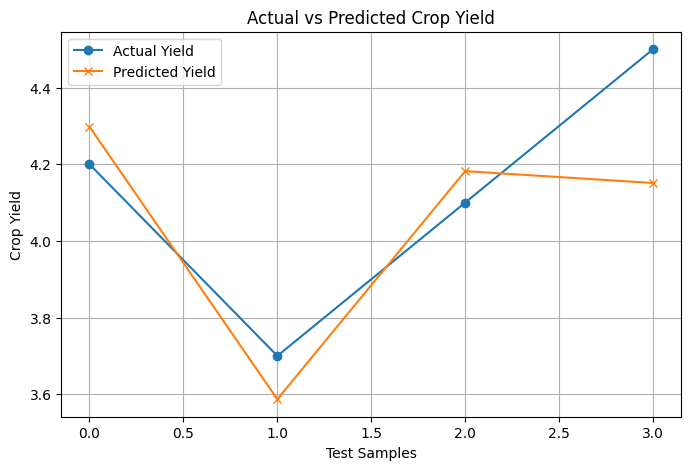


Feature Importance:
           Feature  Importance
1  Soil_Phosphorus    0.205497
0    Soil_Nitrogen    0.178616
4         Rainfall    0.170214
2   Soil_Potassium    0.152110
3      Temperature    0.147440
5         Humidity    0.146124


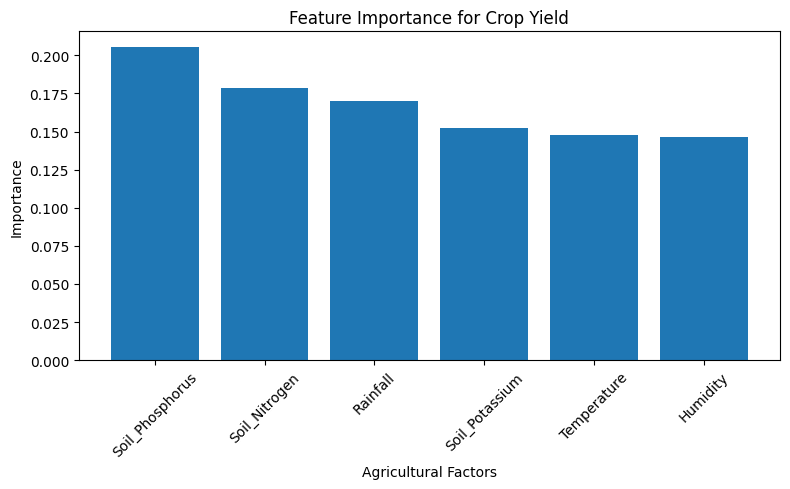


New Farm Information:
   Soil_Nitrogen  Soil_Phosphorus  Soil_Potassium  Temperature  Rainfall  \
0             85               40              50           28       900   

   Humidity  
0        72  

Predicted Crop Yield:
4.45

Farmer Advisory:
Expected yield is moderate. Improve soil nutrients and monitor rainfall.

Crop Yield Forecasting Completed Successfully!


In [3]:
# ============================================================
# CROP YIELD FORECASTING USING SOIL AND CLIMATE DATA
# ============================================================

# STEP 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# STEP 2: Create Sample Agricultural Dataset
# ============================================================

data = {
    "Soil_Nitrogen": [
        80, 70, 90, 60, 75, 85, 65, 95, 72, 88,
        68, 92, 78, 55, 82, 76, 89, 64, 73, 86
    ],

    "Soil_Phosphorus": [
        40, 35, 45, 30, 38, 42, 32, 48, 36, 44,
        34, 46, 39, 28, 41, 37, 43, 31, 35, 40
    ],

    "Soil_Potassium": [
        50, 45, 55, 40, 48, 52, 43, 58, 46, 54,
        44, 57, 49, 38, 51, 47, 53, 42, 45, 50
    ],

    "Temperature": [
        28, 29, 27, 30, 28, 26, 31, 27, 29, 28,
        30, 26, 27, 32, 28, 29, 27, 31, 30, 28
    ],

    "Rainfall": [
        850, 900, 780, 700, 820, 950, 650, 1000, 880, 920,
        720, 980, 800, 600, 870, 850, 790, 680, 750, 910
    ],

    "Humidity": [
        70, 72, 68, 65, 71, 75, 63, 78, 70, 73,
        66, 76, 69, 60, 72, 71, 68, 64, 67, 74
    ],

    "Yield": [
        4.2, 4.5, 4.4, 3.5, 4.1, 4.8, 3.6, 5.0, 4.3, 4.7,
        3.8, 4.9, 4.2, 3.2, 4.4, 4.1, 4.5, 3.7, 4.0, 4.6
    ]
}

df = pd.DataFrame(data)

print("Agricultural Dataset:")
print(df)


# ============================================================
# STEP 3: Display Dataset Information
# ============================================================

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# STEP 4: Separate Input and Output
# ============================================================

X = df[
    [
        "Soil_Nitrogen",
        "Soil_Phosphorus",
        "Soil_Potassium",
        "Temperature",
        "Rainfall",
        "Humidity"
    ]
]

y = df["Yield"]


# ============================================================
# STEP 5: Split Dataset into Training and Testing Data
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# STEP 6: Create Crop Yield Prediction Model
# ============================================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")


# ============================================================
# STEP 7: Predict Crop Yield
# ============================================================

y_pred = model.predict(X_test)

print("\nActual Yield:")
print(y_test.values)

print("\nPredicted Yield:")
print(y_pred)


# ============================================================
# STEP 8: Evaluate the Model
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("----------------------------")
print("Mean Absolute Error:", round(mae, 2))
print("Mean Squared Error:", round(mse, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2 Score:", round(r2, 2))


# ============================================================
# STEP 9: Actual vs Predicted Yield
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker="o",
    label="Actual Yield"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker="x",
    label="Predicted Yield"
)

plt.xlabel("Test Samples")
plt.ylabel("Crop Yield")
plt.title("Actual vs Predicted Crop Yield")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# STEP 10: Feature Importance
# ============================================================

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


# ============================================================
# STEP 11: Feature Importance Graph
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Agricultural Factors")
plt.ylabel("Importance")
plt.title("Feature Importance for Crop Yield")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# ============================================================
# STEP 12: Predict Yield for New Farm Data
# ============================================================

new_farm = pd.DataFrame({
    "Soil_Nitrogen": [85],
    "Soil_Phosphorus": [40],
    "Soil_Potassium": [50],
    "Temperature": [28],
    "Rainfall": [900],
    "Humidity": [72]
})

new_prediction = model.predict(new_farm)

print("\nNew Farm Information:")
print(new_farm)

print("\nPredicted Crop Yield:")
print(round(new_prediction[0], 2))


# ============================================================
# STEP 13: Simple Yield Advisory
# ============================================================

predicted_yield = new_prediction[0]

if predicted_yield >= 4.5:
    advice = "Expected yield is high. Continue proper irrigation and crop management."
elif predicted_yield >= 3.5:
    advice = "Expected yield is moderate. Improve soil nutrients and monitor rainfall."
else:
    advice = "Expected yield is low. Check soil fertility, irrigation and climate conditions."

print("\nFarmer Advisory:")
print(advice)


# ============================================================
# END
# ============================================================

print("\nCrop Yield Forecasting Completed Successfully!")